# Bug and Corrections notebook 

## Imports 

In [2]:
import pandas as pd
import logging
import sys
import numpy as np
from dataclasses import asdict
from pathlib import Path

sys.path.append(r"C:\Users\giuli\Repositories\intraday-momentum\src")
path = "/home/corwyn/Black_swan/Intraday_project/intraday-momentum/"
sys.path.append("/home/corwyn/Black_swan/Intraday_project/intraday-momentum/src")
from classes.metrics.metrics import MetricsCalculator
from classes.backtest.engine import BacktestEngine  
from classes.backtest.default import BacktestDefaults 

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True,   # <-- allow printing in jupyter notebooks
)

logger = logging.getLogger(__name__)


In [3]:
root = path

df_spy = pd.read_pickle(root + "data/cleaned/SPY_1min_20231027_20251027.pkl")
df_spy.drop(columns=["close_deseasonalized"], inplace = True)
df_dividends = pd.read_csv(root + "data/cleaned/SPY_div_2020-2025.csv")

# Print information about the dataframes
df_spy.info()
print("\n")
df_dividends.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 194105 entries, 2023-10-30 09:30:00 to 2025-10-27 15:59:00
Data columns (total 5 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   volume  194105 non-null  float64
 1   open    194105 non-null  float64
 2   high    194105 non-null  float64
 3   low     194105 non-null  float64
 4   close   194105 non-null  float64
dtypes: float64(5)
memory usage: 8.9 MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   caldt     20 non-null     object 
 1   dividend  20 non-null     float64
 2   ticker    20 non-null     object 
dtypes: float64(1), object(2)
memory usage: 612.0+ bytes


### Dividends

In [4]:
# Make a copy
df_dividends_prepared = df_dividends.copy()

# Rename columns to match what MetricsCalculator expects
df_dividends_prepared = df_dividends_prepared.rename(columns={
    "ex_dividend_date": "caldt",  # Metrics expects 'caldt'
    "cash_amount": "dividend"     # Metrics expects 'dividend'
})

# Convert 'caldt' to datetime
df_dividends_prepared["caldt"] = pd.to_datetime(df_dividends_prepared["caldt"])

# Keep only the necessary columns
df_dividends_prepared = df_dividends_prepared[["caldt", "dividend", "ticker"]]

# Verify
print(df_dividends_prepared.head())
print(df_dividends_prepared.columns)

       caldt  dividend ticker
0 2025-09-19   1.83111    SPY
1 2025-06-20   1.76112    SPY
2 2025-03-21   1.69553    SPY
3 2024-12-20   1.96555    SPY
4 2024-09-20   1.74553    SPY
Index(['caldt', 'dividend', 'ticker'], dtype='object')


### Metrics

In [5]:
from classes.metrics.metrics import MetricsCalculator

mc = MetricsCalculator()
mc = MetricsCalculator()
df_spy, df_spy_daily = mc.from_clean_df(df_spy, df_dividends)


2025-12-15 11:58:01,207 | INFO | Starting computation of market microstructure metrics...
2025-12-15 11:58:01,209 | INFO | Computing trading bounds...
2025-12-15 11:58:01,210 | INFO | Computing minute of day...
2025-12-15 11:58:01,302 | INFO | Computing opening prices...
2025-12-15 11:58:01,349 | INFO | Computing price movements...
2025-12-15 11:58:01,353 | INFO | Computing rolling volatility...
2025-12-15 11:58:01,682 | INFO | Computing previous close prices...
2025-12-15 11:58:01,722 | INFO | Computing reference prices...
2025-12-15 11:58:01,838 | INFO | Computing trading bounds...
2025-12-15 11:58:01,844 | INFO | Bounds computation completed.
2025-12-15 11:58:02,989 | INFO | Cleaning dataframe before export...
2025-12-15 11:58:03,059 | INFO | df_all saved to data/processed/df_all_days.pkl
2025-12-15 11:58:03,061 | INFO | df_daily saved to data/processed/df_daily_groups.pkl


In [6]:
df_spy.tail()

,volume,open,high,low,close,minute_of_day,upper_bnd,lower_bnd,vwap
Datetime,,,,,,,,,
2025-10-27 15:55:00,826675.0,685.49,685.520,685.280,685.395,385,687.280558,672.596900,683.661265
2025-10-27 15:56:00,670327.0,685.39,685.540,685.380,685.460,386,687.233091,672.643977,683.685295
2025-10-27 15:57:00,832993.0,685.46,685.460,685.345,685.415,387,687.267715,672.609638,683.713406
2025-10-27 15:58:00,942046.0,685.42,685.425,685.330,685.340,388,687.225009,672.651993,683.743354
2025-10-27 15:59:00,1402531.0,685.34,685.420,685.170,685.180,389,687.055938,672.819671,683.783135


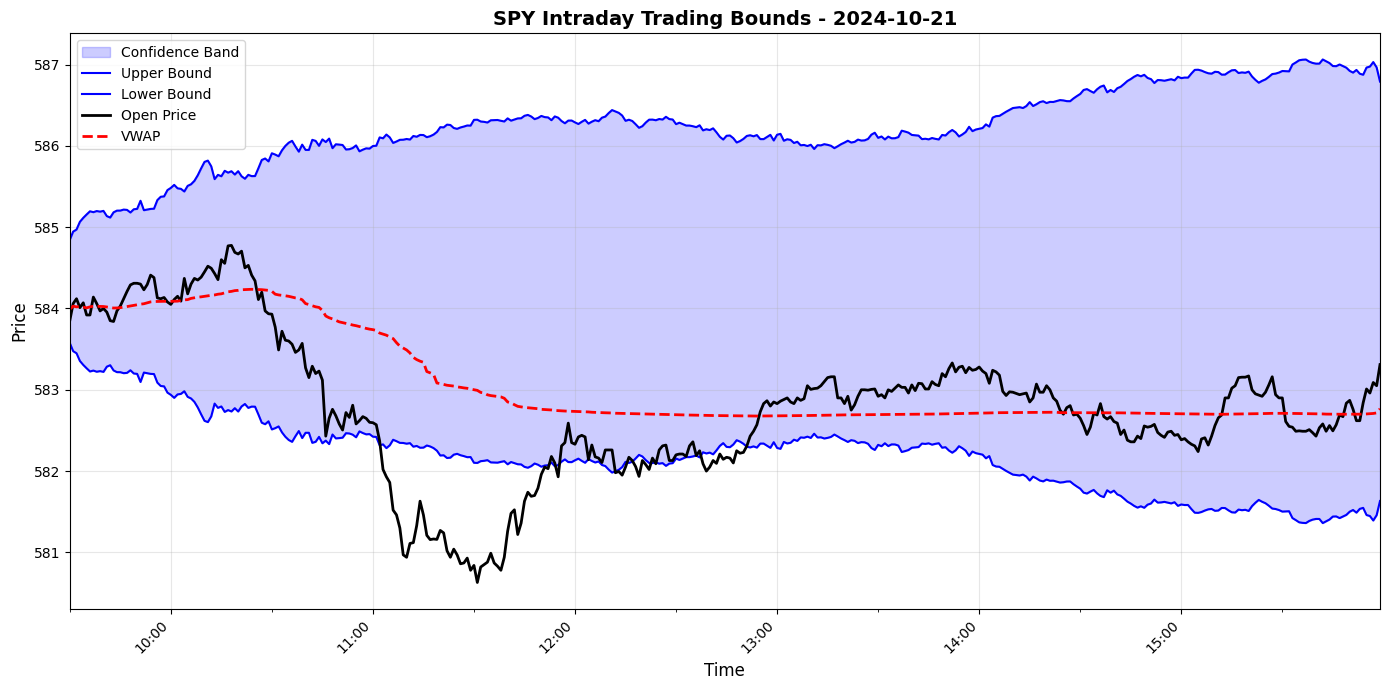

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import pandas as pd
import os


target_date = '2024-10-21'
target_date_dt = pd.to_datetime(target_date)

# Ensure index is datetime
df_spy.index = pd.to_datetime(df_spy.index)

# Filter by the index date
df_day = df_spy[df_spy.index.date == target_date_dt.date()].copy()

if df_day.empty:
    print(f"No intraday data for {target_date}")
    print(f"Available date range: {df_spy.index.min().date()} to {df_spy.index.max().date()}")
else:
    # Set a clean datetime index for matplotlib (use the index which is already datetime)
    if getattr(df_day.index, 'tz', None) is not None:
        try:
            df_day.index = df_day.index.tz_convert(None)
        except Exception:
            try:
                df_day.index = df_day.index.tz_localize(None)
            except Exception:
                pass

    # Create plot
    fig, ax = plt.subplots(figsize=(14, 7))

    # Plot the band with transparency
    ax.fill_between(df_day.index, df_day["lower_bnd"], df_day["upper_bnd"], 
                    alpha=0.2, color='blue', label='Confidence Band')

    # Plot upper and lower bounds
    ax.plot(df_day.index, df_day["upper_bnd"], color='blue', linewidth=1.5, label='Upper Bound')
    ax.plot(df_day.index, df_day["lower_bnd"], color='blue', linewidth=1.5, label='Lower Bound')

    # Plot open price
    ax.plot(df_day.index, df_day["open"], color='black', linewidth=2, label='Open Price')

    # Plot VWAP as dashed line if present
    if "vwap" in df_day.columns:
        ax.plot(df_day.index, df_day["vwap"], color='red', linewidth=2, label='VWAP', linestyle='--')

    # Create explicit major (hourly) and minor (30min) ticks using pandas date_range
    start = df_day.index[0].floor('h')
    end = df_day.index[-1].ceil('h')
    major_ticks = pd.date_range(start=start, end=end, freq='60min')
    minor_ticks = pd.date_range(start=start, end=end, freq='30min')

    ax.set_xticks(major_ticks)
    ax.set_xticks(minor_ticks, minor=True)
    ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))

    # Tight x-limits and formatting
    ax.set_xlim([df_day.index[0], df_day.index[-1]])
    plt.xticks(rotation=45, ha='right')

    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(f'SPY Intraday Trading Bounds - {target_date}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.show()

### Backtests

In [ ]:
from classes.backtest.engine_new import Momentum
from backtesting import Backtest

bt = Backtest(
            data =df_spy,
            strategy = Momentum,
            cash = 100000,
            comission = 0.035,
            spread = 0.01
            )

stats = bt.run()

print(stats)